In [96]:
from sklearn import datasets
import matplotlib.pyplot as plt 
import numpy as np
from sklearn.manifold import Isomap
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import requests
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, silhouette_score
from sklearn.base import BaseEstimator, ClusterMixin
import warnings
from sklearn.cluster import KMeans
from sklearn import preprocessing
from sklearn.metrics import confusion_matrix

(1797, 8, 8)
dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])


In [ ]:
# Dimensionalitty reduction

In [97]:
import urllib.request
urllib.request.urlretrieve("https://raw.githubusercontent.com/nshaud/ml_for_astro/main/stars.csv", "stars.csv");

In [98]:
import pandas as pd
df_stars = pd.read_csv("stars.csv")

In [99]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
# Assign unique integers from 0 to 6 to each star type
df_stars['Star type'] = le.fit_transform(df_stars['Star type'])
labels = le.inverse_transform(df_stars['Star type'])
class_names = le.classes_
print(class_names)

['Brown Dwarf' 'Hypergiant' 'Main Sequence' 'Red Dwarf' 'Supergiant'
 'White Dwarf']


In [100]:
df_stars #seems that there is 6 differentes numerical dimensions 

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,0,Red,M
1,3042,0.000500,0.1542,16.60,0,Red,M
2,2600,0.000300,0.1020,18.70,0,Red,M
3,2800,0.000200,0.1600,16.65,0,Red,M
4,1939,0.000138,0.1030,20.06,0,Red,M
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,1,Blue,O
236,30839,834042.000000,1194.0000,-10.63,1,Blue,O
237,8829,537493.000000,1423.0000,-10.73,1,White,A
238,9235,404940.000000,1112.0000,-11.23,1,White,A


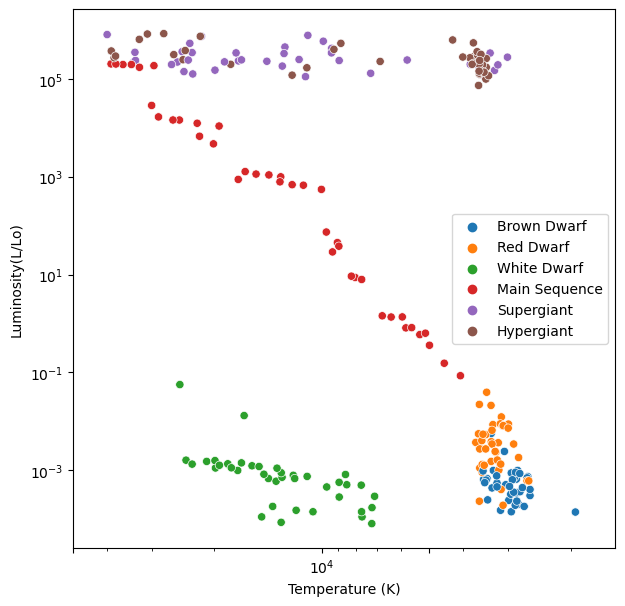

In [101]:
import seaborn as sns

fig = plt.figure(figsize=(7, 7))
sns.scatterplot(data=df_stars, x='Temperature (K)', y='Luminosity(L/Lo)', hue=labels)

plt.xscale('log')
plt.yscale('log')
plt.xticks([5000, 10000, 50000])
plt.xlim(5e4, 1.5e3)
plt.show()

In [102]:
df_num = df_stars.drop(columns=['Star color', 'Spectral Class']) # we leave onyl numerical data
from sklearn.decomposition import PCA

pca = PCA(n_components=2) # n_components can be optionally set
pca.fit(df_num) 

PCA(n_components=2)

In [103]:
projected_stars = pca.fit_transform(df_num) #we do the projections

<Figure size 700x700 with 0 Axes>

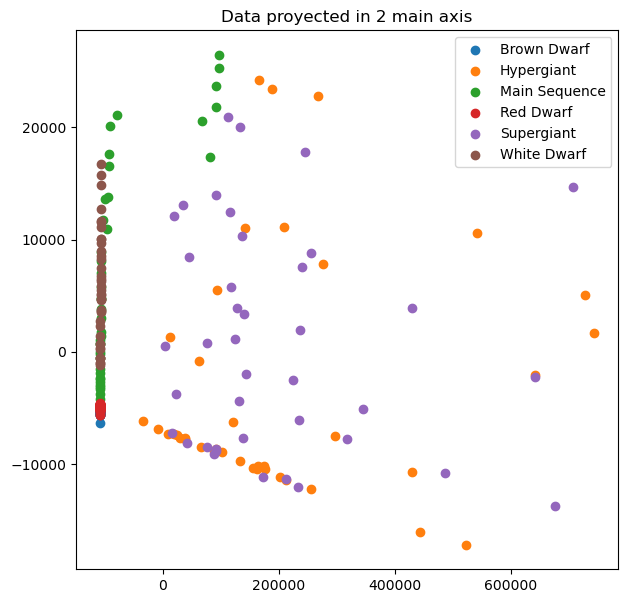

In [104]:
fig = plt.figure(figsize=(7, 7))
df = pd.DataFrame({'x': projected_stars[:, 0],'y': projected_stars[:, 1],'label': labels})

fig = plt.figure(figsize=(7, 7))
for name, group in df.groupby('label'):
    plt.scatter(group.x, group.y, label=name)
plt.title('Data proyected in 2 main axis')
plt.legend()
plt.show()

In [105]:
X = df_num.values
mean = X.mean(axis=0)
std = X.std(axis=0)

X_scaled = (X - mean) / std

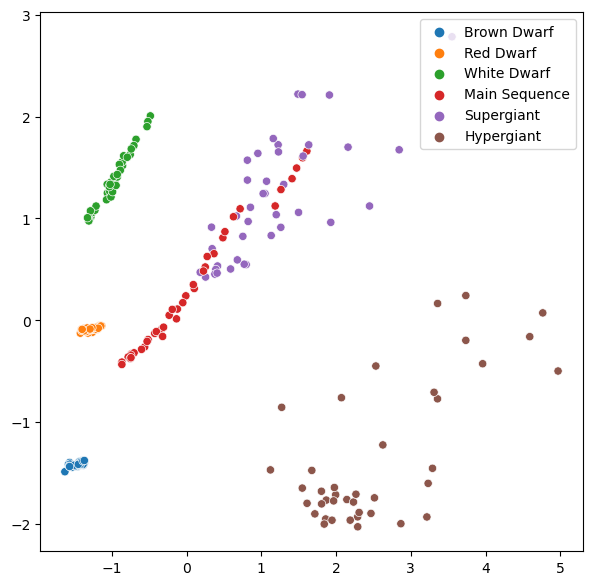

In [106]:
pca = PCA(n_components=2)
pca.fit(X_scaled)
projected_stars = pca.fit_transform(X_scaled)

fig = plt.figure(figsize=(7, 7))
sns.scatterplot(x=projected_stars[:,0], y=projected_stars[:,1], hue=labels) # i will try this simplified version
plt.show()

#a bit better but why

In [107]:
#lets try that all the data goes from -1 to 1
#from sklearn.preprocessing import MinMaxScaler

#scaler = MinMaxScaler(feature_range=(-1, 1))
#X_scaled = scaler.fit_transform(df_num)

X_min = X.min(axis=0)
X_max = X.max(axis=0)
a, b = -1, 1

X_scaled_2 = a + ((X - X_min) / (X_max - X_min)) * (b - a)

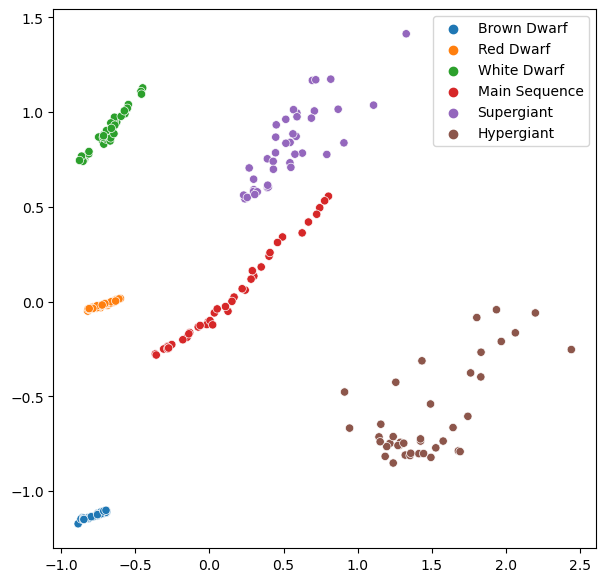

In [108]:
pca = PCA(n_components=2)
pca.fit(X_scaled_2)
projected_stars_2 = pca.fit_transform(X_scaled_2)

fig = plt.figure(figsize=(7, 7))
sns.scatterplot(x=projected_stars_2[:,0], y=projected_stars_2[:,1], hue=labels)
plt.show()

#can we do clustering on this?? ofccc

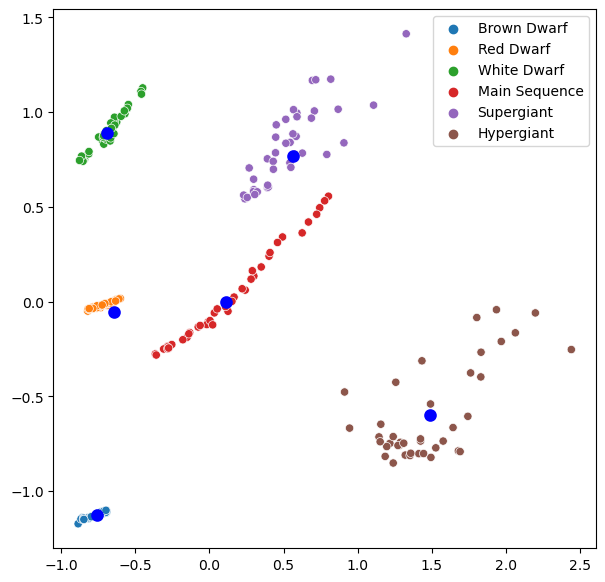

In [111]:
clf = KMeans(n_clusters=6,n_init='auto')
clf.fit(projected_stars_2)
centers = clf.cluster_centers_ #location of the clusters in 2d
labels_2 = clf.predict(projected_stars_2) #labels for each of the points, a que clase pertenece??

fig = plt.figure(figsize=(7, 7))
sns.scatterplot(x=projected_stars_2[:,0], y=projected_stars_2[:,1], hue=labels)
plt.scatter(centers[:, 0], centers[:, 1], color='blue', marker='o', s=50, linewidth=2, label='Centroids')
plt.show()

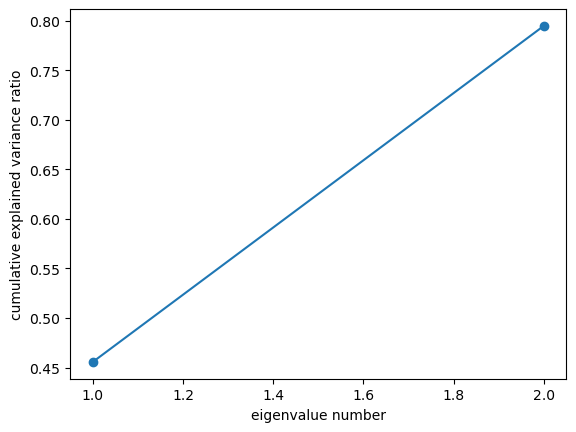

In [77]:
eigen = pca.explained_variance_ratio_ 
plt.plot([1,2], eigen.cumsum())
plt.scatter([1,2], eigen.cumsum())

plt.xlabel("eigenvalue number")
plt.ylabel("cumulative explained variance ratio")
plt.show()

#how many % there are in the first 2 componets